In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("survey lung cancer.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (309, 16)
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                    2     

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Columns:
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']

Data Types:
GENDER                   object
AGE                       int64
SMOKING                   int64
YELLOW_FINGERS            int64
ANXIETY                   int64
PEER_PRESSURE             int64
CHRONIC DISEASE           int64
FATIGUE                   int64
ALLERGY                   int64
WHEEZING                  int64
ALCOHOL CONSUMING         int64
COUGHING                  int64
SHORTNESS OF BREATH       int64
SWALLOWING DIFFICULTY     int64
CHEST PAIN                int64
LUNG_CANCER              object
dtype: object

Missing Values:
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGU

In [4]:
print("\nUnique values:")
for col in df.columns:
    print(col, ":", df[col].nunique())

print("\nTarget candidates:")
print(df.columns)


Unique values:
GENDER : 2
AGE : 39
SMOKING : 2
YELLOW_FINGERS : 2
ANXIETY : 2
PEER_PRESSURE : 2
CHRONIC DISEASE : 2
FATIGUE  : 2
ALLERGY  : 2
WHEEZING : 2
ALCOHOL CONSUMING : 2
COUGHING : 2
SHORTNESS OF BREATH : 2
SWALLOWING DIFFICULTY : 2
CHEST PAIN : 2
LUNG_CANCER : 2

Target candidates:
Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='object')


In [5]:
print(df.describe(include="all").T)

                       count unique  top freq       mean       std   min  \
GENDER                   309      2    M  162        NaN       NaN   NaN   
AGE                    309.0    NaN  NaN  NaN  62.673139  8.210301  21.0   
SMOKING                309.0    NaN  NaN  NaN   1.563107  0.496806   1.0   
YELLOW_FINGERS         309.0    NaN  NaN  NaN   1.569579  0.495938   1.0   
ANXIETY                309.0    NaN  NaN  NaN   1.498382  0.500808   1.0   
PEER_PRESSURE          309.0    NaN  NaN  NaN   1.501618  0.500808   1.0   
CHRONIC DISEASE        309.0    NaN  NaN  NaN   1.504854  0.500787   1.0   
FATIGUE                309.0    NaN  NaN  NaN   1.673139  0.469827   1.0   
ALLERGY                309.0    NaN  NaN  NaN   1.556634  0.497588   1.0   
WHEEZING               309.0    NaN  NaN  NaN   1.556634  0.497588   1.0   
ALCOHOL CONSUMING      309.0    NaN  NaN  NaN   1.556634  0.497588   1.0   
COUGHING               309.0    NaN  NaN  NaN   1.579288  0.494474   1.0   
SHORTNESS OF

In [6]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape: (276, 16)
Duplicates: 0


In [7]:
print(df.isnull().sum().sort_values(ascending=False))

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'LUNG_CANCER']


In [9]:
print(df["LUNG_CANCER"].value_counts())
print()
print(df["LUNG_CANCER"].value_counts(normalize=True))

LUNG_CANCER
YES    238
NO      38
Name: count, dtype: int64

LUNG_CANCER
YES    0.862319
NO     0.137681
Name: proportion, dtype: float64


In [10]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

GENDER: ['M' 'F']
AGE: [69 74 59 63 75 52 51 68 53 61 72 60 58 48 57 44 64 21 65 55 62 56 67 77
 70 54 49 73 47 71 66 76 78 81 79 38 39 87 46]
SMOKING: [1 2]
YELLOW_FINGERS: [2 1]
ANXIETY: [2 1]
PEER_PRESSURE: [1 2]
CHRONIC_DISEASE: [1 2]
FATIGUE: [2 1]
ALLERGY: [1 2]
WHEEZING: [2 1]
ALCOHOL_CONSUMING: [2 1]
COUGHING: [2 1]
SHORTNESS_OF_BREATH: [2 1]
SWALLOWING_DIFFICULTY: [2 1]
CHEST_PAIN: [2 1]
LUNG_CANCER: ['YES' 'NO']


In [11]:
df_master = df.copy()
df_work = df_master.copy()

In [12]:
df_work["LUNG_CANCER"] = df_work["LUNG_CANCER"].map({
    "NO": 0,
    "YES": 1
})

In [13]:
binary_features = [
    "SMOKING",
    "YELLOW_FINGERS",
    "ANXIETY",
    "PEER_PRESSURE",
    "CHRONIC_DISEASE",
    "FATIGUE",
    "ALLERGY",
    "WHEEZING",
    "ALCOHOL_CONSUMING",
    "COUGHING",
    "SHORTNESS_OF_BREATH",
    "SWALLOWING_DIFFICULTY",
    "CHEST_PAIN"
]

for col in binary_features:
    df_work[col] = df_work[col].map({
        1: 0,
        2: 1
    })

In [14]:
df_work["GENDER"] = df_work["GENDER"].map({
    "M": 1,
    "F": 0
})

print(df_work.head())
print(df_work.dtypes)

   GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0       1   69        0               1        1              0   
1       1   74        1               0        0              0   
2       0   59        0               0        0              1   
3       1   63        1               1        1              0   
4       0   63        0               1        0              0   

   CHRONIC_DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL_CONSUMING  COUGHING  \
0                0        1        0         1                  1         1   
1                1        1        1         0                  0         0   
2                0        1        0         1                  0         1   
3                0        0        0         0                  1         0   
4                0        0        0         1                  0         1   

   SHORTNESS_OF_BREATH  SWALLOWING_DIFFICULTY  CHEST_PAIN  LUNG_CANCER  
0                    1                      1    

In [15]:
X = df_work.drop("LUNG_CANCER", axis=1)
y = df_work["LUNG_CANCER"]

print("X:", X.shape)
print("y:", y.shape)

X: (276, 15)
y: (276,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (220, 15)
X_test : (56, 15)
y_train: (220,)
y_test : (56,)


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numerical_features = ["AGE"]

binary_features = [
    "GENDER",
    "SMOKING",
    "YELLOW_FINGERS",
    "ANXIETY",
    "PEER_PRESSURE",
    "CHRONIC_DISEASE",
    "FATIGUE",
    "ALLERGY",
    "WHEEZING",
    "ALCOHOL_CONSUMING",
    "COUGHING",
    "SHORTNESS_OF_BREATH",
    "SWALLOWING_DIFFICULTY",
    "CHEST_PAIN"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("bin", "passthrough", binary_features)
])

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(probability=True, random_state=42))
    ]),

    "Naive Bayes": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GaussianNB())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, model):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [20]:
results = []

for name, model in models.items():
    results.append(evaluate_model(name, model))

results_df = pd.DataFrame(results)

In [21]:
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,Decision Tree,0.928571,0.978261,0.937500,0.957447,0.906250
0,Logistic Regression,0.910714,0.921569,0.979167,0.949495,0.945312
5,Random Forest,0.910714,0.938776,0.958333,0.948454,0.958333
3,Naive Bayes,0.892857,0.920000,0.958333,0.938776,0.953125
1,KNN,0.875000,0.886792,0.979167,0.930693,0.881510
2,SVM,0.857143,0.884615,0.958333,0.920000,0.937500


In [22]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="ROC-AUC Mean",
    ascending=False
)

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.909091,0.930382,0.968421,0.948629,0.928070,0.027404
5,Random Forest,0.895455,0.920245,0.963158,0.940765,0.912281,0.026462
2,SVM,0.895455,0.907880,0.978947,0.941680,0.892105,0.038095
3,Naive Bayes,0.881818,0.923537,0.942105,0.932294,0.873684,0.048556
1,KNN,0.881818,0.911224,0.957895,0.933135,0.802632,0.100648
4,Decision Tree,0.854545,0.917539,0.915789,0.915602,0.691228,0.128250


In [23]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

lr_grid = GridSearchCV(
    models["Logistic Regression"],
    lr_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Params:", lr_grid.best_params_)
print("Best CV ROC-AUC:", lr_grid.best_score_)

Best Params: {'model__C': 0.001, 'model__class_weight': None, 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.9359649122807017


In [24]:
lr_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    models["Logistic Regression"],
    lr_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Params:", lr_grid.best_params_)
print("Best CV ROC-AUC:", lr_grid.best_score_)

Best Params: {'model__C': 0.01, 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.9254385964912281


In [25]:
svm_params = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    models["SVM"],
    svm_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Params:", svm_grid.best_params_)
print("Best CV ROC-AUC:", svm_grid.best_score_)

Best Params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV ROC-AUC: 0.9219298245614036


In [26]:
final_candidates = {
    "Logistic Regression": lr_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_
}

final_results = []

for name, model in final_candidates.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.857143,0.857143,1.000000,0.923077,0.973958
1,SVM,0.910714,0.921569,0.979167,0.949495,0.971354


In [27]:
best_model_name = final_results_df.loc[
    final_results_df["ROC-AUC"].idxmax(),
    "Model"
]

best_model = final_candidates[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [28]:
best_model = lr_grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8571428571428571
Precision: 0.8571428571428571
Recall   : 1.0
F1       : 0.9230769230769231
ROC-AUC  : 0.9739583333333334


[[ 0  8]
 [ 0 48]]


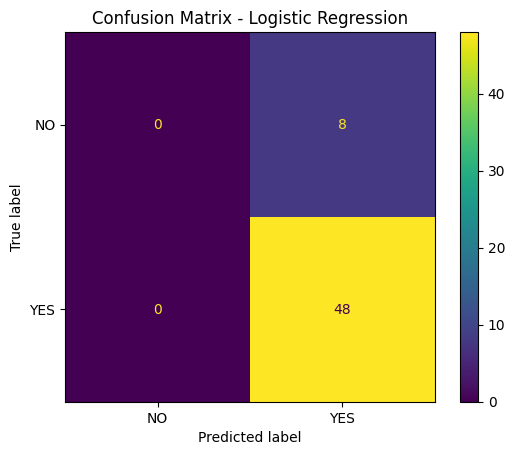

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NO", "YES"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [30]:
print("Actual:")
print(y_test.value_counts())

print("\nPredicted:")
print(pd.Series(y_pred).value_counts())

Actual:
LUNG_CANCER
1    48
0     8
Name: count, dtype: int64

Predicted:
1    56
Name: count, dtype: int64


In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["NO", "YES"]
    )
)

              precision    recall  f1-score   support

          NO       0.00      0.00      0.00         8
         YES       0.86      1.00      0.92        48

    accuracy                           0.86        56
   macro avg       0.43      0.50      0.46        56
weighted avg       0.73      0.86      0.79        56



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


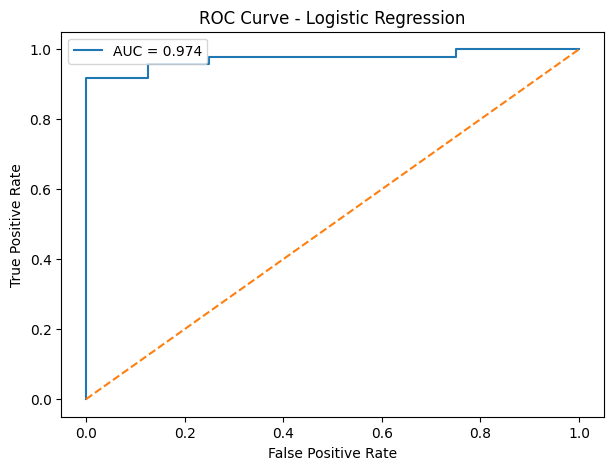

In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

PR-AUC: 0.9959386840870585


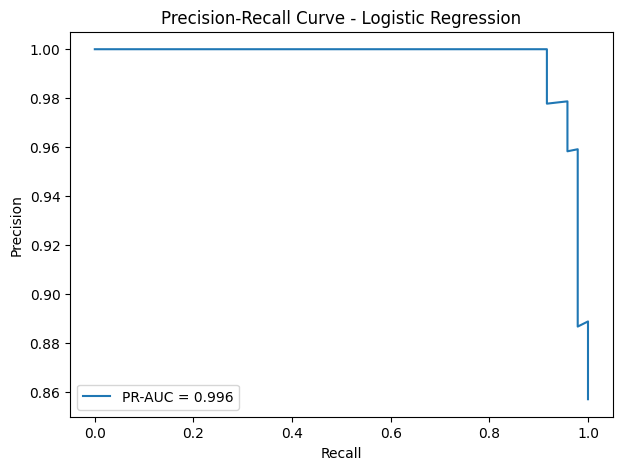

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.show()

In [34]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = best_model.named_steps[
    "model"
].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
8,bin__ALLERGY,0.184764,0.184764
10,bin__ALCOHOL_CONSUMING,0.176852,0.176852
3,bin__YELLOW_FINGERS,0.157074,0.157074
7,bin__FATIGUE,0.155545,0.155545
6,bin__CHRONIC_DISEASE,0.153726,0.153726
11,bin__COUGHING,0.153517,0.153517
5,bin__PEER_PRESSURE,0.150963,0.150963
14,bin__CHEST_PAIN,0.150718,0.150718
9,bin__WHEEZING,0.146736,0.146736
13,bin__SWALLOWING_DIFFICULTY,0.146589,0.146589


In [35]:
feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
8,bin__ALLERGY,0.184764,0.184764
10,bin__ALCOHOL_CONSUMING,0.176852,0.176852
3,bin__YELLOW_FINGERS,0.157074,0.157074
7,bin__FATIGUE,0.155545,0.155545
6,bin__CHRONIC_DISEASE,0.153726,0.153726
11,bin__COUGHING,0.153517,0.153517
5,bin__PEER_PRESSURE,0.150963,0.150963
14,bin__CHEST_PAIN,0.150718,0.150718
9,bin__WHEEZING,0.146736,0.146736
13,bin__SWALLOWING_DIFFICULTY,0.146589,0.146589


In [36]:
import joblib

joblib.dump(
    best_model,
    "lung_cancer_best_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [37]:
final_summary = pd.DataFrame([{
    "Best Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": pr_auc
}])

final_summary

,Best Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.857143,0.857143,1.0,0.923077,0.973958,0.995939


In [38]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

cv_results_df.to_csv(
    "cross_validation_results.csv",
    index=False
)

final_summary.to_csv(
    "final_model_results.csv",
    index=False
)

## Deployment-Safe Model Artifact
Save the final Logistic Regression model as a version-independent parameter dictionary instead of a scikit-learn Pipeline pickle.

In [ ]:
import sklearn
import joblib

print('scikit-learn:', sklearn.__version__)

In [ ]:
# Refit the selected Logistic Regression model on the training split.
best_model = lr_grid.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))


In [ ]:
# Extract only plain numerical parameters needed for inference.
fitted_preprocessor = best_model.named_steps['preprocessor']
fitted_scaler = fitted_preprocessor.named_transformers_['num']
fitted_lr = best_model.named_steps['model']

artifact = {
    'type': 'lung_cancer_logistic_v1',
    'feature_order': ['AGE'] + binary_features,
    'age_mean': float(fitted_scaler.mean_[0]),
    'age_scale': float(fitted_scaler.scale_[0]),
    'coef': fitted_lr.coef_[0].astype(float).tolist(),
    'intercept': float(fitted_lr.intercept_[0]),
    'classes': fitted_lr.classes_.tolist(),
}

print('Artifact created.')
print('Features:', artifact['feature_order'])


In [ ]:
joblib.dump(artifact, 'lung_cancer_best_model.pkl')
print('Saved: lung_cancer_best_model.pkl')


In [ ]:
loaded_artifact = joblib.load('lung_cancer_best_model.pkl')
print(type(loaded_artifact))
print('Reload successful ✅')


In [ ]:
X_test_arr = X_test[loaded_artifact['feature_order']].to_numpy(dtype=float)
X_test_arr[:, 0] = (X_test_arr[:, 0] - loaded_artifact['age_mean']) / loaded_artifact['age_scale']

z = X_test_arr @ np.asarray(loaded_artifact['coef']) + loaded_artifact['intercept']
prob_reload = 1 / (1 + np.exp(-z))
pred_reload = (prob_reload >= 0.5).astype(int)

print('Reloaded Accuracy:', accuracy_score(y_test, pred_reload))
print('Reloaded ROC-AUC:', roc_auc_score(y_test, prob_reload))


## Deployment Files

In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
joblib==1.5.3


In [ ]:
import os
for file in ['lung_cancer_best_model.pkl', 'requirements.txt']:
    print(file, '→', os.path.exists(file))
